# Telco Customer Churn

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

https://community.ibm.com/community/user/blogs/steven-macko/2019/07/11/telco-customer-churn-1113

In [733]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

np.set_printoptions(precision=2, suppress=True)
pd.options.display.float_format = '{:.2f}'.format

In [734]:
df = pd.read_csv('./data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.rename(columns={
    'customerID': 'CustomerID',
    'gender': 'Gender',
    'tenure': 'Tenure',
}, inplace=True)
df.shape
df.head(1).iloc[:, :10]
df.head(1).iloc[:, 10:]

(7043, 21)

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No


,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


## Looking at cols

In [735]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   str    
 1   Gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [736]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

In [737]:
num_cols = df.select_dtypes(['number']).columns
cat_cols = df.select_dtypes(['str']).columns

num_cols = [col for col in num_cols if col not in ['Churn']]
cat_cols = [col for col in cat_cols if col not in ['CustomerID']]

print(len(num_cols), num_cols)
print(len(cat_cols), cat_cols)

3 ['Tenure', 'MonthlyCharges', 'TotalCharges']
16 ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Numerical cols distribution

,Tenure,MonthlyCharges,TotalCharges,Churn
min,0.00,18.25,18.80,0.00
max,72.00,118.75,8684.80,1.00
mean,32.37,64.76,2283.30,0.27
75%,55.00,89.85,3794.74,1.00


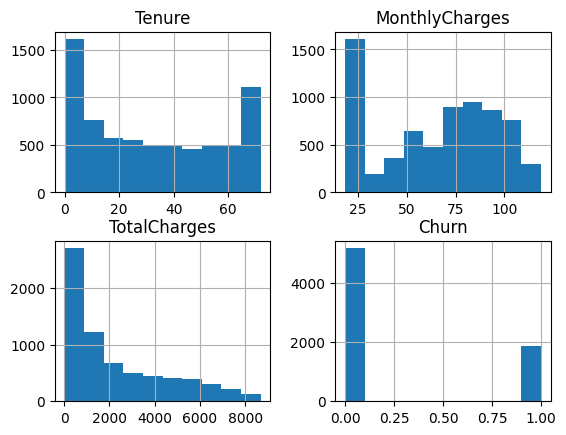

In [738]:
df.describe().loc[['min', 'max', 'mean', '75%']]
_ = df.hist()

## Categorical cols distribution

In [739]:
for col in cat_cols:
  df[col] = df[col].replace({
      'No phone service': 'No',
      'No internet service': 'No',
      'Bank transfer (automatic)': 'Bank transfer',
      'Credit card (automatic)': 'Credit card',
  })
  print(col, df[col].nunique(), df[col].unique()[:5].tolist())

Gender 2 ['Female', 'Male']
SeniorCitizen 2 ['No', 'Yes']
Partner 2 ['Yes', 'No']
Dependents 2 ['No', 'Yes']
PhoneService 2 ['No', 'Yes']
MultipleLines 2 ['No', 'Yes']
InternetService 3 ['DSL', 'Fiber optic', 'No']
OnlineSecurity 2 ['No', 'Yes']
OnlineBackup 2 ['Yes', 'No']
DeviceProtection 2 ['No', 'Yes']
TechSupport 2 ['No', 'Yes']
StreamingTV 2 ['No', 'Yes']
StreamingMovies 2 ['No', 'Yes']
Contract 3 ['Month-to-month', 'One year', 'Two year']
PaperlessBilling 2 ['Yes', 'No']
PaymentMethod 4 ['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card']


## Target distribution

In [740]:


pd.concat([
    df['Churn'].value_counts(),
    df['Churn'].value_counts(normalize=True) * 100
], axis=1)

,count,proportion
Churn,,
0,5174,73.46
1,1869,26.54


## Data cleaning (duplicates, missing values)

In [741]:
df['CustomerID'].duplicated().sum()

np.int64(0)

In [742]:
nulls = df.isnull().sum()
nulls[nulls.gt(0)]

TotalCharges    11
dtype: int64

In [743]:
df['TotalCharges'].median()

np.float64(1397.475)

In [744]:
# Likely new customers
df.loc[df['TotalCharges'].isnull(), 'Tenure'].value_counts()
df.loc[df['TotalCharges'].isnull(), 'MonthlyCharges'].value_counts()

Tenure
0    11
Name: count, dtype: int64

MonthlyCharges
52.55    1
20.25    1
80.85    1
25.75    1
56.05    1
19.85    1
25.35    1
20.00    1
19.70    1
73.35    1
61.90    1
Name: count, dtype: int64

In [745]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

## Outliers analysis

In [746]:
summary = []

for col in num_cols:
  if col == 'SeniorCitizen':
    continue

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  outlier_count = len(outliers)
  outlier_percent = (outlier_count / len(df)) * 100

  summary.append({
      'Column': col,
      'Lower Bound': f"{lower_bound:.2f}",
      'Upper Bound': f"{upper_bound:.2f}",
      'Outliers Count': outlier_count,
      'Outliers %': f"{outlier_percent:.1f}%",
  })

pd.DataFrame(summary)

,Column,Lower Bound,Upper Bound,Outliers Count,Outliers %
0,Tenure,-60.00,124.00,0,0.0%
1,MonthlyCharges,-46.02,171.38,0,0.0%
2,TotalCharges,-4683.52,8868.67,0,0.0%


## Validate business logic

In [747]:
diff = abs(df['Tenure'] * df['MonthlyCharges'] - df['TotalCharges'])
(diff == 0).sum()
(~(diff == 0)).sum()

np.int64(614)

np.int64(6429)

In [748]:
suspicious = diff > df['MonthlyCharges'] * 3
suspicious.sum()
print(f'{(suspicious.sum() / len(df) * 100):.2f}%')

np.int64(172)

2.44%


## Exploratory data analysis

### Categorical Variables vs Churn

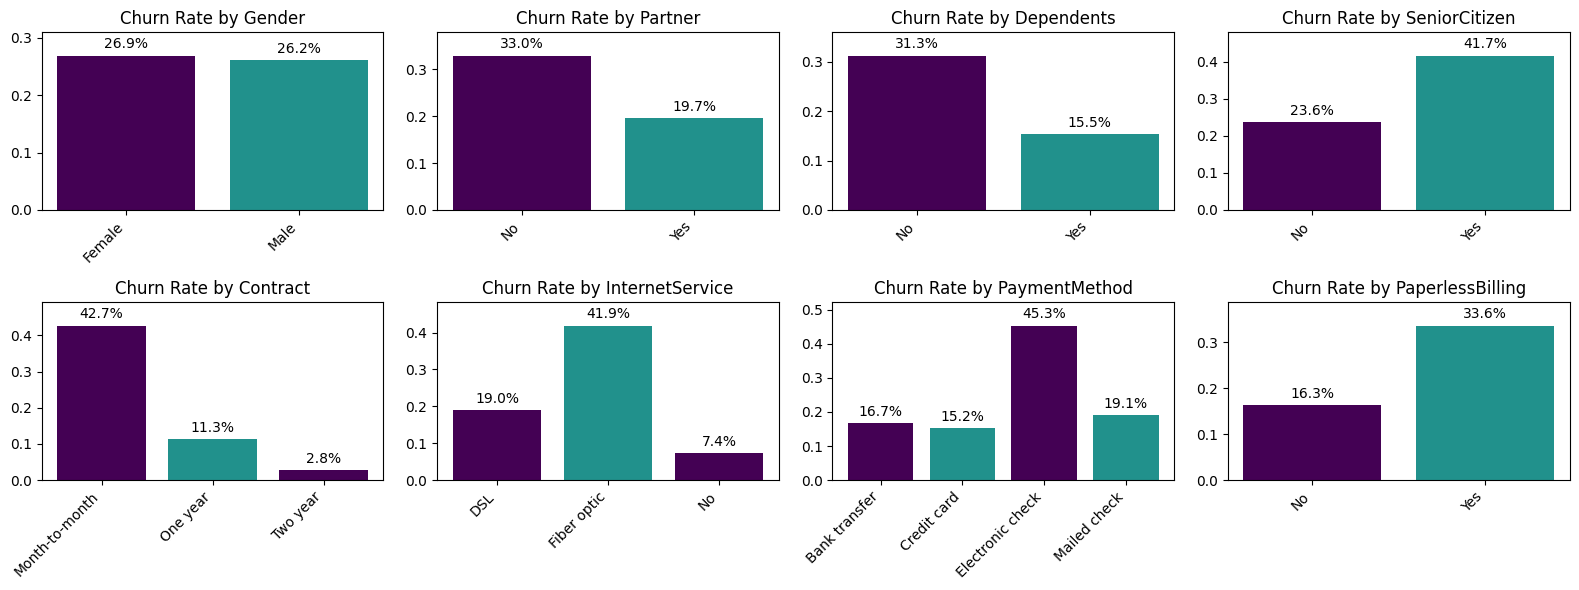

In [749]:
cols = ['Gender', 'Partner', 'Dependents', 'SeniorCitizen',
        'Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(cols):
  means = df.groupby(col)['Churn'].mean()

  bars = axes[i].bar(means.index.astype(str), means, color=['#440154', '#21918c'])
  _ = axes[i].set_title(f'Churn Rate by {col}')

  # Add x% labels on top
  _ = axes[i].bar_label(bars, fmt='%.1f%%', padding=3, labels=[f'{x*100:.1f}%' for x in means])
  _ = axes[i].set_ylim(0, means.max() * 1.15)
  _ = plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()

### Numerical Variables vs Churn

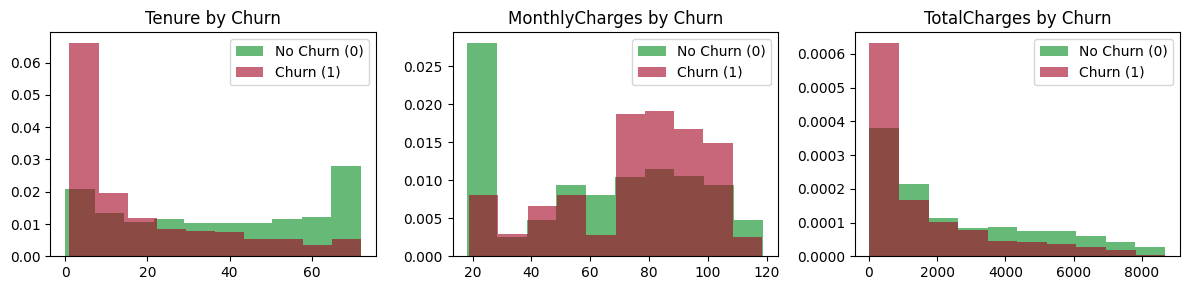

In [750]:
cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for i, col in enumerate(cols):
  churn_1 = df.loc[df['Churn'] == 1, col]
  churn_0 = df.loc[df['Churn'] == 0, col]

  _ = axes[i].hist(churn_0, bins=10, alpha=0.6, label='No Churn (0)', color="#008B1C", density=True)
  _ = axes[i].hist(churn_1, bins=10, alpha=0.6, label='Churn (1)', color="#A40021", density=True)

  _ = axes[i].set_title(f'{col} by Churn')
  _ = axes[i].legend()

plt.tight_layout()

### Churn Rate by Tenure Group

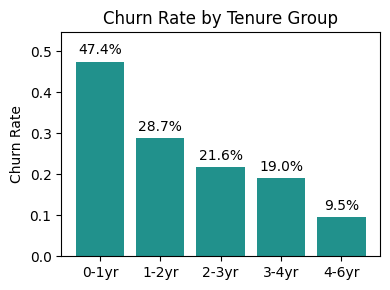

In [751]:
bins = [0, 12, 24, 36, 48, 72]
labels = ['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-6yr']

df['Tenure_Group'] = pd.cut(df['Tenure'], bins=bins, labels=labels, include_lowest=True)
means = df.groupby('Tenure_Group')['Churn'].mean()

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(means.index.astype(str), means, color='#21918c')

_ = ax.set_title('Churn Rate by Tenure Group')
_ = ax.set_ylabel('Churn Rate')

_ = ax.bar_label(bars, padding=3, labels=[f'{x*100:.1f}%' for x in means])
_ = ax.set_ylim(0, means.max() * 1.15)

plt.tight_layout()

### Churn Rate by Number of Services

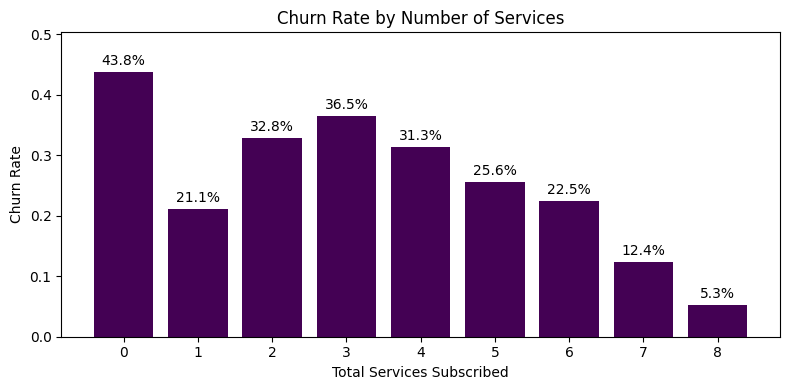

In [752]:
cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['ServiceCount'] = 0
for col in cols:
  df['ServiceCount'] += (df[col] == 'Yes').astype(int)

means = df.groupby('ServiceCount')['Churn'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(means.index.astype(str), means, color='#440154')

_ = ax.set_title('Churn Rate by Number of Services')
_ = ax.set_xlabel('Total Services Subscribed')
_ = ax.set_ylabel('Churn Rate')

_ = ax.bar_label(bars, padding=3, labels=[f'{x*100:.1f}%' for x in means])
_ = ax.set_ylim(0, means.max() * 1.15)

plt.tight_layout()

### Monthly Charges vs Tenure

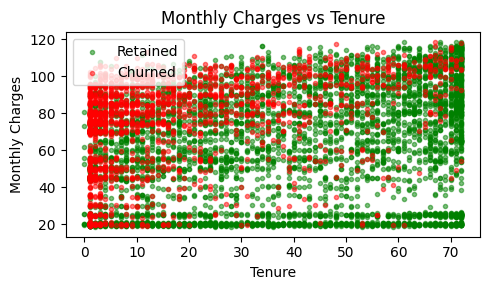

In [753]:
fig, ax = plt.subplots(figsize=(5, 3))

# Plot Retained (Green)
_ = ax.scatter(df.loc[df['Churn'] == 0, 'Tenure'],
               df.loc[df['Churn'] == 0, 'MonthlyCharges'],
               color='green', label='Retained', alpha=0.5, marker='.')

# Plot Churned (Red)
_ = ax.scatter(df.loc[df['Churn'] == 1, 'Tenure'],
               df.loc[df['Churn'] == 1, 'MonthlyCharges'],
               color='red', label='Churned', alpha=0.5, marker='.')

_ = ax.set_title('Monthly Charges vs Tenure')
_ = ax.set_xlabel('Tenure')
_ = ax.set_ylabel('Monthly Charges')
_ = ax.legend()

plt.tight_layout()

### Correlation matrix

In [754]:
corr = df[num_cols + ['ServiceCount', 'Churn']].corr().abs()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_upper = corr.where(mask & corr.gt(0.2)).fillna('-')
corr_upper

,Tenure,MonthlyCharges,TotalCharges,ServiceCount,Churn
Tenure,-,0.25,0.83,0.52,0.35
MonthlyCharges,-,-,0.65,0.80,-
TotalCharges,-,-,-,0.80,-
ServiceCount,-,-,-,-,-
Churn,-,-,-,-,-


## Feature engineering and preprocessing